In [10]:
import sys
import logging
import json
from pathlib import Path
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd().parent / "src"))

# Spotipy/urllib3 Stderr-Noise bei 429 unterdruecken (bringt nur Verwirrung,
# unsere eigene SpotifyRateLimitError reicht).
logging.getLogger("spotipy").setLevel(logging.CRITICAL)
logging.getLogger("urllib3").setLevel(logging.CRITICAL)

%load_ext autoreload
%autoreload 2

from spotify_scraper import (
    get_spotify_client,
    get_artist_albums,
    prune_cache,
    SpotifyRateLimitError,
)
from cover_downloader import download_all_covers

sp = get_spotify_client()
print("Spotify-Client initialisiert")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Spotify-Client initialisiert


In [11]:
# artists.json laden und in DataFrame flatten. Jede Zeile = 1 Artist mit ID.
artists_json_path = Path.cwd().parent / "src" / "artists.json"
with open(artists_json_path, "r", encoding="utf-8") as f:
    genre_artists = json.load(f)

rows = []
missing_ids = []
for genre, entries in genre_artists.items():
    for entry in entries:
        if not entry.get("id"):
            missing_ids.append((genre, entry["name"]))
            continue
        rows.append({
            "genre": genre,
            "artist_name": entry["name"],
            "artist_id": entry["id"],
        })

artists_df = pd.DataFrame(rows)
print(f"{len(artists_df)} Artists mit ID")
print(artists_df.groupby("genre").size().sort_values(ascending=False))

if missing_ids:
    print(f"\n{len(missing_ids)} Artists ohne ID — werden uebersprungen:")
    for genre, name in missing_ids:
        print(f"   [{genre}] {name}")

200 Artists mit ID
genre
alternative_rock    20
classical           20
country             20
hiphop              20
house               20
indie_rock          20
jazz                20
metal               20
reggae              20
techno              20
dtype: int64


In [12]:
# Cache-Hygiene: alte Eintraege aus frueheren Artist-Sets entfernen.
# Behaelt nur Cache-Daten fuer Artists, die jetzt noch in artists.json stehen.
removed = prune_cache(set(artists_df["artist_id"]))
print(f"Cache aufgeraeumt: {len(removed)} alte Eintraege entfernt")

Cache aufgeraeumt: 0 alte Eintraege entfernt


In [13]:
# Pro Artist alle Alben holen. Ergebnisse werden in data/spotify_cache.json gecached.
# Bei Daily-Cap ueberspringen wir betroffene Artists (per-artist try/except) —
# beim naechsten Lauf werden sie nachgezogen.
# Wenn ALLE rate-limited sind (= 0 Alben gesammelt), brechen wir hart ab.
from datetime import datetime, timedelta

all_albums = []
rate_limited = []  # (genre, artist_name, retry_after_seconds)

for _, artist_row in tqdm(artists_df.iterrows(), total=len(artists_df), desc="Alben abrufen"):
    try:
        albums = get_artist_albums(sp, artist_row["artist_id"])
    except SpotifyRateLimitError as e:
        rate_limited.append((artist_row["genre"], artist_row["artist_name"], e.retry_after_seconds))
        continue
    for album in albums:
        album["genre"] = artist_row["genre"]
        album["artist_name"] = artist_row["artist_name"]
        all_albums.append(album)

albums_df = pd.DataFrame(all_albums)

if albums_df.empty:
    retry_secs = max((s for *_, s in rate_limited if s), default=None)
    if retry_secs:
        unblock_at = datetime.now() + timedelta(seconds=retry_secs)
        wait_msg = (
            f"Wieder frei in ~{retry_secs / 3600:.1f}h "
            f"(ca. {unblock_at.strftime('%Y-%m-%d %H:%M')})."
        )
    else:
        wait_msg = "Spotify hat keinen Retry-After-Header geliefert — bei Daily-Cap typisch ~24h."
    raise RuntimeError(
        f"Keine Alben gesammelt — alle {len(rate_limited)} Artists rate-limited. {wait_msg}"
    )

print(f"\n{len(albums_df)} Alben insgesamt gesammelt ({len(artists_df) - len(rate_limited)}/{len(artists_df)} Artists)")
print(f"   Unique Album-IDs: {albums_df['album_id'].nunique()}")
print(f"   (Differenz = Alben, die mehreren Artists zugeordnet werden, z.B. Collabs)")
if rate_limited:
    retry_secs = max((s for *_, s in rate_limited if s), default=None)
    if retry_secs:
        unblock_at = datetime.now() + timedelta(seconds=retry_secs)
        print(
            f"\n{len(rate_limited)} Artists Rate-Limited — wieder frei in ~{retry_secs / 3600:.1f}h "
            f"(ca. {unblock_at.strftime('%Y-%m-%d %H:%M')}):"
        )
    else:
        print(f"\n{len(rate_limited)} Artists Rate-Limited (kein Retry-After-Header):")
    for genre, name, _ in rate_limited[:10]:
        print(f"   [{genre}] {name}")
    if len(rate_limited) > 10:
        print(f"   ... und {len(rate_limited) - 10} weitere")


Alben abrufen: 100%|██████████| 200/200 [00:08<00:00, 22.99it/s]


729 Alben insgesamt gesammelt (50/200 Artists)
   Unique Album-IDs: 579
   (Differenz = Alben, die mehreren Artists zugeordnet werden, z.B. Collabs)

150 Artists Rate-Limited (kein Retry-After-Header):
   [hiphop] Ice Cube
   [hiphop] Lil Wayne
   [hiphop] 50 Cent
   [hiphop] Tyler, The Creator
   [hiphop] Mac Miller
   [hiphop] Apache 207
   [hiphop] Haftbefehl
   [hiphop] Kontra K
   [hiphop] Marteria
   [hiphop] OutKast
   ... und 140 weitere


In [14]:
genre_stats = albums_df.groupby("genre").agg(
    anzahl_alben=("album_id", "nunique"),
    anzahl_artists=("artist_id", "nunique"),
).sort_values("anzahl_alben", ascending=False)

print(genre_stats)

           anzahl_alben  anzahl_artists
genre                                  
metal               293              20
classical           152              20
hiphop              134              10


In [15]:
data_dir = Path.cwd().parent / "data"
data_dir.mkdir(exist_ok=True)

artists_df.to_csv(data_dir / "artists_raw.csv", index=False)
albums_df.to_csv(data_dir / "albums_raw.csv", index=False)

print(f"Gespeichert:")
print(f"   {data_dir / 'artists_raw.csv'} ({len(artists_df)} Zeilen)")
print(f"   {data_dir / 'albums_raw.csv'} ({len(albums_df)} Zeilen)")

Gespeichert:
   /Users/tjarek/uni/album-genre-classifier/data/artists_raw.csv (200 Zeilen)
   /Users/tjarek/uni/album-genre-classifier/data/albums_raw.csv (729 Zeilen)


In [16]:
# Cover-Bilder runterladen nach data/covers/{genre}/{album_id}.jpg.
# Globale Deduplizierung nach album_id (Collabs landen nur in einem Genre).
# Resume-fähig: bestehende Dateien werden uebersprungen.
download_all_covers()

Geplant: 579  |  schon vorhanden: 579  |  zu laden: 0
{'geplant': 579, 'uebersprungen': 579, 'neu_geladen': 0, 'fehlgeschlagen': 0}


{'geplant': 579, 'uebersprungen': 579, 'neu_geladen': 0, 'fehlgeschlagen': 0}

In [17]:
# Sanity-Check: tatsaechlich vorhandene Cover pro Genre auf der Disk zaehlen.
# Hilft Class-Imbalance vorm Training zu erkennen.
covers_dir = Path.cwd().parent / "data" / "covers"
counts = {
    g.name: len(list(g.glob("*.jpg")))
    for g in sorted(covers_dir.iterdir())
    if g.is_dir()
}
total = sum(counts.values())

print(f"Cover auf Disk (gesamt: {total})")
for genre, n in sorted(counts.items(), key=lambda x: -x[1]):
    bar = "█" * int(n / max(counts.values()) * 30) if counts.values() else ""
    print(f"   {genre:<20s} {n:>4d}  {bar}")

Cover auf Disk (gesamt: 579)
   metal                 293  ██████████████████████████████
   classical             152  ███████████████
   hiphop                134  █████████████


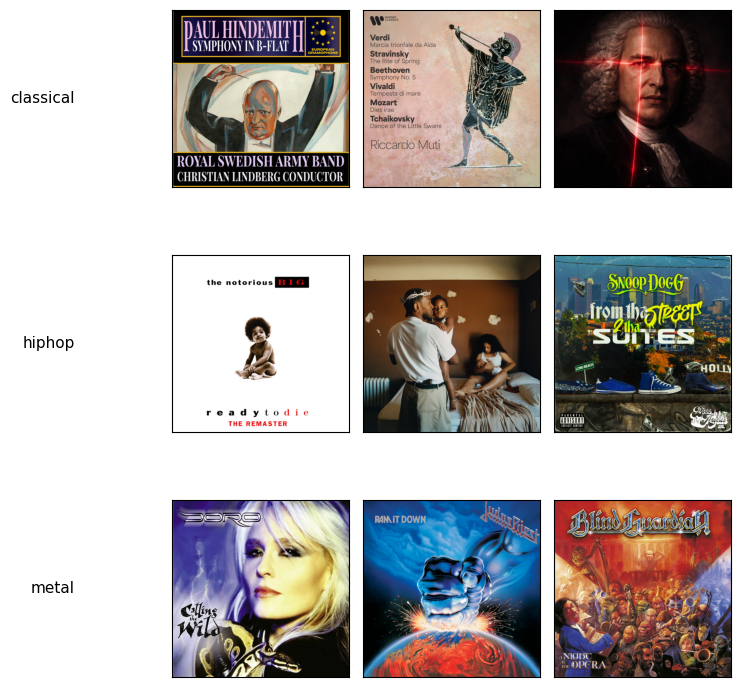

In [18]:
# Visual Sanity-Check: 3 Zufalls-Cover pro Genre als Grid anzeigen.
# Schneller Eyeball-Check ob die Genre-Cover plausibel aussehen vor Training.
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

genres_with_covers = sorted([
    g for g in covers_dir.iterdir() if g.is_dir() and any(g.glob("*.jpg"))
])

if not genres_with_covers:
    print("Keine Cover gefunden — erst download_all_covers() ausfuehren.")
else:
    n_samples = 3
    fig, axes = plt.subplots(
        len(genres_with_covers), n_samples,
        figsize=(n_samples * 2.5, len(genres_with_covers) * 2.5),
    )
    if len(genres_with_covers) == 1:
        axes = axes.reshape(1, -1)

    for row, genre_dir in enumerate(genres_with_covers):
        files = list(genre_dir.glob("*.jpg"))
        sample = random.sample(files, min(n_samples, len(files)))
        for col in range(n_samples):
            ax = axes[row, col]
            ax.set_xticks([])
            ax.set_yticks([])
            if col < len(sample):
                ax.imshow(Image.open(sample[col]))
        axes[row, 0].set_ylabel(
            genre_dir.name, rotation=0, labelpad=70,
            fontsize=11, va="center", ha="right",
        )

    plt.tight_layout()
    plt.show()